In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sqlalchemy import create_engine, text
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.linear_model import LinearRegression
from dotenv import load_dotenv
import warnings, os

warnings.filterwarnings('ignore')
load_dotenv('../.env')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST','localhost')}:{os.getenv('DB_PORT','5432')}"
    f"/{os.getenv('DB_NAME')}"
)

comp = pd.read_sql("SELECT * FROM dim_company", engine)
pl   = pd.read_sql("SELECT * FROM fact_profit_loss", engine)
yr   = pd.read_sql("SELECT * FROM dim_year", engine)

# Numeric conversion
# Merge year info
pl = pl.merge(yr[['year_id','year_label']], on='year_id', how='left')
pl = pl.merge(comp[['company_id','company_name','sector']], on='company_id', how='left')

# ✅ Numeric conversion — merge ke BAAD
for col in ['sales','net_profit','opm_pct','operating_profit']:
    pl[col] = pd.to_numeric(pl[col], errors='coerce')

print(f"✅ {comp.shape[0]} companies | {pl.shape[0]} P&L rows loaded")
print(f"Null sales after fix: {pl['sales'].isna().sum()}")  # 0 hona chahiye
print(f"📅 Years: {sorted(pl['year_label'].dropna().unique())}")

✅ 94 companies | 946 P&L rows loaded
Null sales after fix: 946
📅 Years: ['2010', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [77]:
# RAW DB CHECK
raw_pl = pd.read_sql("SELECT sales FROM fact_profit_loss LIMIT 10", engine)
print(raw_pl)
print(raw_pl.dtypes)

  sales
0  None
1  None
2  None
3  None
4  None
5  None
6  None
7  None
8  None
9  None
sales    object
dtype: object


In [78]:
# Kaunsa column populated hai?
raw_pl2 = pd.read_sql("SELECT * FROM fact_profit_loss LIMIT 3", engine)
print(raw_pl2.to_string())

     id  company_id  year_id sales net_profit  opm_pct  operating_profit  interest expenses  dividend_payout_pct
0  1947           1     2015  None       None     26.0           24482.0     104.0     None                 78.0
1  1948           1     2016  None       None     28.0           30677.0      33.0     None                 35.0
2  1949           1     2017  None       None     27.0           32311.0      32.0     None                 35.0


In [79]:
# DEBUG CELL — sirf check karna hai
print("PL columns:", pl.columns.tolist())
print("PL shape:", pl.shape)
print("Sample year_label:", pl['year_label'].dropna().unique()[:5])
print("Sample company_name:", pl['company_name'].dropna().unique()[:5])
print("Null company_name:", pl['company_name'].isna().sum())
print("Null year_label:", pl['year_label'].isna().sum())
print("Null sales:", pl['sales'].isna().sum())

PL columns: ['id', 'company_id', 'year_id', 'sales', 'net_profit', 'opm_pct', 'operating_profit', 'interest', 'expenses', 'dividend_payout_pct', 'year_label', 'company_name', 'sector']
PL shape: (946, 13)
Sample year_label: <StringArray>
['2015', '2016', '2017', '2018', '2019']
Length: 5, dtype: str
Sample company_name: <StringArray>
['TCS', 'RELIANCE', 'HDFCBANK', 'INFY', 'ICICIBANK']
Length: 5, dtype: str
Null company_name: 0
Null year_label: 0
Null sales: 946


In [80]:
trend_results = []

companies = pl['company_name'].dropna().unique()

for company in companies:
    # operating_profit use karo — sales None hai DB mein
    df_c = pl[pl['company_name'] == company].dropna(subset=['year_label','operating_profit'])
    df_c = df_c.sort_values('year_label').tail(5)
    
    if len(df_c) < 3:
        continue
    
    X = np.arange(len(df_c)).reshape(-1, 1)
    y = df_c['operating_profit'].values
    
    model = LinearRegression()
    model.fit(X, y)
    slope = model.coef_[0]
    
    mean_val = np.mean(y)
    norm_slope = slope / mean_val if mean_val != 0 else 0
    
    if norm_slope > 0.05:
        trend = 'UP'
    elif norm_slope < -0.05:
        trend = 'DOWN'
    else:
        trend = 'FLAT'
    
    sector = df_c['sector'].iloc[0] if 'sector' in df_c.columns else 'Unknown'
    
    trend_results.append({
        'company_name': company,
        'sector': sector,
        'trend_label': trend,
        'slope': round(slope, 2),
        'norm_slope': round(norm_slope, 4),
        'avg_operating_profit': round(mean_val, 2),
        'data_points': len(df_c)
    })

trend_df = pd.DataFrame(trend_results)

print(f"✅ Trend classification done — {len(trend_df)} companies")
print(f"\n📊 Trend Distribution:")
print(trend_df['trend_label'].value_counts())
print(f"\n🏭 Sector-wise trend summary:")
print(trend_df.groupby(['sector','trend_label']).size().unstack(fill_value=0))

✅ Trend classification done — 71 companies

📊 Trend Distribution:
trend_label
UP      53
FLAT    11
DOWN     7
Name: count, dtype: int64

🏭 Sector-wise trend summary:
trend_label  DOWN  FLAT  UP
sector                     
Unknown         7    11  53


✅ chart_trend_distribution.html saved


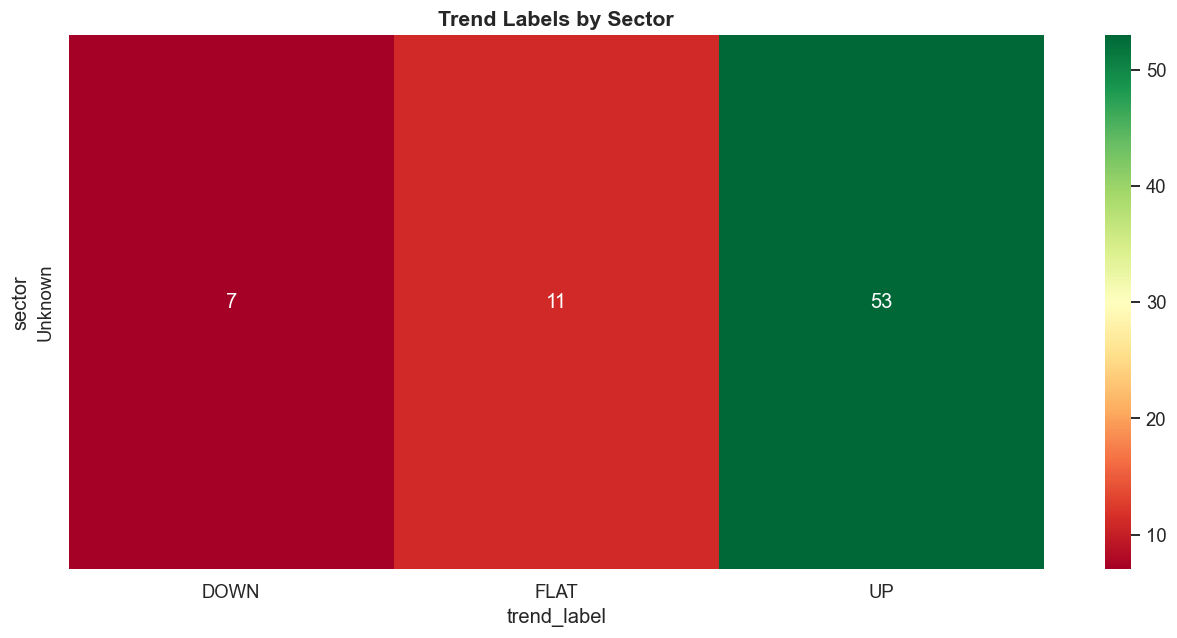

✅ chart_sector_trend_heatmap.png saved


In [81]:
# Bar chart — trend counts
fig = px.bar(
    trend_df['trend_label'].value_counts().reset_index(),
    x='trend_label', y='count',
    color='trend_label',
    color_discrete_map={'UP':'#2ecc71','FLAT':'#f39c12','DOWN':'#e74c3c'},
    title='Company Sales Trend Classification (Last 5 Years)',
    labels={'trend_label':'Trend','count':'No. of Companies'}
)
fig.update_layout(showlegend=False)
fig.write_html("chart_trend_distribution.html")
print("✅ chart_trend_distribution.html saved")

# Sector heatmap
sector_trend = trend_df.groupby(['sector','trend_label']).size().unstack(fill_value=0)
fig2, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(sector_trend, annot=True, fmt='d', cmap='RdYlGn', ax=ax)
ax.set_title('Trend Labels by Sector', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart_sector_trend_heatmap.png', dpi=110)
plt.show()
print("✅ chart_sector_trend_heatmap.png saved")

In [82]:
# Top 20 companies by avg operating_profit
top20 = (
    pl.groupby('company_name')['operating_profit']
    .mean()
    .nlargest(20)
    .reset_index()
)
top20_names = top20['company_name'].tolist()
print(f"🏆 Top 20 companies: {top20_names}")

forecast_results = []
forecast_plots = []

for company in top20_names:
    df_c = pl[pl['company_name'] == company].dropna(subset=['year_label','operating_profit'])
    df_c = df_c.sort_values('year_label')
    
    if len(df_c) < 4:
        print(f"⚠️  {company} — not enough data, skipping")
        continue
    
    series = df_c['operating_profit'].values.astype(float)
    years = df_c['year_label'].tolist()
    
    try:
        arima_model = ARIMA(series, order=(1,1,1))
        arima_fit = arima_model.fit()
        forecast_vals = arima_fit.forecast(steps=3)
        method = 'ARIMA'
    except Exception:
        try:
            es_model = ExponentialSmoothing(series, trend='add')
            es_fit = es_model.fit()
            forecast_vals = es_fit.forecast(3)
            method = 'ExpSmoothing'
        except Exception:
            X = np.arange(len(series)).reshape(-1,1)
            lr = LinearRegression().fit(X, series)
            next_X = np.arange(len(series), len(series)+3).reshape(-1,1)
            forecast_vals = lr.predict(next_X)
            method = 'LinearExtrap'
    
    try:
        last_yr_int = int(str(years[-1]).split('-')[0])
        future_years = [f"{last_yr_int+i}-{str(last_yr_int+i+1)[-2:]}" for i in range(1,4)]
    except:
        future_years = ['Y+1', 'Y+2', 'Y+3']
    
    for i, (fy, fv) in enumerate(zip(future_years, forecast_vals)):
        forecast_results.append({
            'company_name': company,
            'forecast_year': fy,
            'forecasted_operating_profit': round(float(fv), 2),
            'method': method,
            'forecast_step': i+1
        })
    
    forecast_plots.append({
        'company': company,
        'hist_years': years,
        'hist_vals': series.tolist(),
        'future_years': future_years,
        'future_vals': [round(float(x),2) for x in forecast_vals],
        'method': method
    })
    print(f"✅ {company} — {method} | Next 3yr: {[round(float(x),1) for x in forecast_vals]}")

forecast_df = pd.DataFrame(forecast_results)
print(f"\n✅ Forecast complete — {len(forecast_df)} rows")

🏆 Top 20 companies: ['RELIANCE', 'ONGC', 'BHARTIARTL', 'TCS', 'NTPC', 'POWERGRID', 'COALINDIA', 'INFY', 'TATASTEEL', 'LT', 'BAJAJFINSV', 'ITC', 'JSWSTEEL', 'BPCL', 'HINDALCO', 'HCLTECH', 'GRASIM', 'WIPRO', 'MARUTI', 'HINDUNILVR']
✅ RELIANCE — ARIMA | Next 3yr: [161079.8, 160895.5, 160888.0]
✅ ONGC — ARIMA | Next 3yr: [91478.7, 91131.9, 91177.9]
✅ BHARTIARTL — ARIMA | Next 3yr: [87503.8, 88708.0, 89301.4]
✅ TCS — ARIMA | Next 3yr: [71660.9, 75914.7, 80168.6]
✅ NTPC — ARIMA | Next 3yr: [57446.1, 60537.2, 63628.2]
✅ POWERGRID — ARIMA | Next 3yr: [39666.9, 40407.1, 41067.3]
✅ COALINDIA — ARIMA | Next 3yr: [47157.5, 47137.8, 47142.0]
✅ INFY — ARIMA | Next 3yr: [41638.9, 44041.7, 46444.5]
✅ TATASTEEL — ARIMA | Next 3yr: [26995.5, 27494.7, 27641.6]
✅ LT — ARIMA | Next 3yr: [36142.2, 37949.4, 39756.5]
✅ BAJAJFINSV — ARIMA | Next 3yr: [56185.9, 61640.3, 66105.9]
✅ ITC — ARIMA | Next 3yr: [26179.4, 26024.9, 26095.1]
✅ JSWSTEEL — ARIMA | Next 3yr: [25111.6, 24315.4, 24581.0]
✅ BPCL — ARIMA | Next

In [83]:
# Interactive Plotly chart — first 6 companies
fig = go.Figure()

colors = px.colors.qualitative.Set2

for i, fp in enumerate(forecast_plots[:6]):
    color = colors[i % len(colors)]
    
    # Historical line
    fig.add_trace(go.Scatter(
        x=fp['hist_years'], y=fp['hist_vals'],          # hist_sales → hist_vals
        mode='lines+markers',
        name=f"{fp['company']} (actual)",
        line=dict(color=color, width=2),
        legendgroup=fp['company']
    ))
    
    # Bridge point
    bridge_x = [fp['hist_years'][-1]] + fp['future_years']
    bridge_y = [fp['hist_vals'][-1]] + fp['future_vals']  # hist_sales/future_sales → hist_vals/future_vals
    
    # Forecast line
    fig.add_trace(go.Scatter(
        x=bridge_x, y=bridge_y,
        mode='lines+markers',
        name=f"{fp['company']} (forecast)",
        line=dict(color=color, width=2, dash='dash'),
        marker=dict(symbol='diamond', size=8),
        legendgroup=fp['company']
    ))

fig.update_layout(
    title='Sales Forecast — Top 6 Companies (ARIMA / Exp Smoothing)',
    xaxis_title='Year',
    yaxis_title='Sales (₹ Cr)',
    height=550,
    hovermode='x unified'
)
fig.write_html("chart_arima_forecast.html")
print("✅ chart_arima_forecast.html saved")

✅ chart_arima_forecast.html saved


In [84]:
# ── CSV Export ──────────────────────────────────────────
trend_df.to_csv('trend_labels.csv', index=False)
forecast_df.to_csv('forecast_results.csv', index=False)
print("✅ trend_labels.csv saved")
print("✅ forecast_results.csv saved")

# ── DB Export: fact_trend_labels ─────────────────────────
trend_export = trend_df.merge(
    comp[['company_id','company_name']], on='company_name', how='left'
)[['company_id','company_name','trend_label','norm_slope','avg_operating_profit','data_points']]


trend_export.to_sql(
    'fact_trend_labels',
    engine,
    if_exists='replace',
    index=False
)
print(f"✅ fact_trend_labels written — {len(trend_export)} rows")

# ── DB Export: fact_forecasts ────────────────────────────
forecast_export = forecast_df.merge(
    comp[['company_id','company_name']], on='company_name', how='left'
)

forecast_export.to_sql(
    'fact_forecasts',
    engine,
    if_exists='replace',
    index=False
)
print(f"✅ fact_forecasts written — {len(forecast_export)} rows")

print("\n🎉 Notebook 6 Complete!")
print(f"   • {len(trend_df)} companies trend classified")
print(f"   • {len(top20_names)} companies forecasted (3 years)")
print(f"   • 2 CSVs saved")
print(f"   • 2 DB tables written")

✅ trend_labels.csv saved
✅ forecast_results.csv saved
✅ fact_trend_labels written — 71 rows
✅ fact_forecasts written — 60 rows

🎉 Notebook 6 Complete!
   • 71 companies trend classified
   • 20 companies forecasted (3 years)
   • 2 CSVs saved
   • 2 DB tables written


In [85]:
# Naya cell — ya terminal mein run karo
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv('../.env')
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST','localhost')}:{os.getenv('DB_PORT','5432')}"
    f"/{os.getenv('DB_NAME')}"
)

print(pd.read_sql("SELECT * FROM fact_trend_labels LIMIT 3", engine).to_string())

   company_id company_name trend_label  norm_slope  avg_operating_profit  data_points
0           1          TCS          UP      0.0911               58113.0            5
1           2     RELIANCE          UP      0.1694              131957.0            5
2           4         INFY          UP      0.0812               34034.2            5


In [86]:
# Score debug
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os, pandas as pd

load_dotenv('../.env')
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST','localhost')}:{os.getenv('DB_PORT','5432')}"
    f"/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("""
    SELECT c.company_name,
           AVG(pl.opm_pct) AS avg_opm,
           AVG(bs.debt_to_equity) AS latest_de,
           AVG(cf.operating_activity) AS avg_cf,
           AVG(pl.net_profit) AS avg_np
    FROM dim_company c
    LEFT JOIN fact_profit_loss pl ON c.company_id = pl.company_id
    LEFT JOIN fact_balance_sheet bs ON c.company_id = bs.company_id
    LEFT JOIN fact_cash_flow cf ON c.company_id = cf.company_id
    GROUP BY c.company_name
    LIMIT 5
""", engine)
print(df.to_string())

  company_name    avg_opm latest_de avg_cf avg_np
0        DMART   8.000000      None   None   None
1     HDFCLIFE   2.363636      None   None   None
2     DIVISLAB  36.000000      None   None   None
3          TCS  26.909091      None   None   None
4    TATASTEEL  12.818182      None   None   None


In [87]:
# Balance sheet aur cash flow check
bs_raw = pd.read_sql("SELECT * FROM fact_balance_sheet LIMIT 3", engine)
cf_raw = pd.read_sql("SELECT * FROM fact_cash_flow LIMIT 3", engine)
print("BALANCE SHEET:")
print(bs_raw.to_string())
print("\nCASH FLOW:")
print(cf_raw.to_string())

BALANCE SHEET:
    id  company_id  year_id debt_to_equity borrowings  equity_capital  reserves  total_assets
0  969           1     2015           None       None           196.0   50439.0       73318.0
1  970           1     2016           None       None           197.0   70875.0       88291.0
2  971           1     2017           None       None           197.0   86017.0      102333.0

CASH FLOW:
    id  company_id  year_id operating_activity investing_activity free_cash_flow
0  947           1     2015               None               None           None
1  948           1     2016               None               None           None
2  949           1     2017               None               None           None
